# Propuesta a fin de 2007 y comparación con 2008

**Regla de oro:** todo lo que sustenta una propuesta usa solo datos de años ≤ 2007. 2008 se usa únicamente como examen.

| Parte | Pregunta | Sustento (≤2007) | Examen (2008) |
|---|---|---|---|
| 1 | ¿Cuánto del rendimiento es solo madurez? | Rendimiento corregido por humedad y madurez, con pendientes de ≤2007 | ¿Los marcadores de rendimiento seleccionan líneas tardías? |
| 2 | ¿Qué regiones/haplotipos se recomiendan? | Descubrimiento 2000–2005, replicación 2006–2007 (efectos dentro de familia) | Puntaje con esas regiones vs rendimiento observado de 2008, frente a conjuntos de SNPs al azar |
| 3 | ¿Qué líneas se proponen para continuar? | Tres criterios: fenotipo global, fenotipo dentro de familia, marcadores (validación cruzada por año) | **Concordancia**: ¿las líneas de 2008 son parientes cercanos (distancia genética) de lo propuesto? **Resultado**: ¿rinden más las de 2008 cercanas a lo propuesto? Con control de propuestas al azar |
| 4 | ¿Cuántos ambientes por línea? | Confiabilidad de la media de una línea según cuántas observaciones tiene | — |

Las mismas pruebas de la parte 3 se repiten para años anteriores (retrospectivas) para ver si el resultado de 2008 es consistente.

**Prerrequisito:** `build_dataset.py` ya ejecutado. Empieza con `QUICK_RUN = True`.

In [2]:
import sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import squareform


def find_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / "DIGITALTOOL").is_dir():
            return d
    raise FileNotFoundError("Run the notebook from inside the Hackolombia repo")


BASE_DIR = find_root(Path.cwd().resolve())
DATA_DIR = BASE_DIR / "DIGITALTOOL" / "data" / "processed" / "prediction"
sys.path.insert(0, str(BASE_DIR / "DIGITALTOOL" / "src" / "03_prediction"))
from ridge_temporal import pearson, metrics
import marker_candidates as mc
import build_dataset as bd

In [3]:
QUICK_RUN = True   # True: fewer permutations, only test year 2008

CFG = dict(
    disc_years=(2000, 2005),       # marker discovery
    rep_years=(2006, 2007),        # marker replication (still before 2008)
    t_disc=4.0, t_rep=2.0,
    ld_distance=0.5,
    ridge_lambda=1000.0,           # within-family ridge, target in sd units
    n_pcs=50, knn=20,
    budgets=[0.2, 0.5] if QUICK_RUN else [0.1, 0.2, 0.3, 0.5],
    backtest_years=[2008] if QUICK_RUN else [2005, 2006, 2007, 2008],
    n_null=30 if QUICK_RUN else 200,
    n_boot=200 if QUICK_RUN else 1000,
)

## Datos

In [4]:
X, lines, snp_names = mc.load_genotypes()      # imputed + standardized with pre-2008 statistics
years = lines["YEAR"].to_numpy()
pops = lines["POP"].to_numpy()
codes, _ = pd.factorize(pops)
Xw = X.copy()                                    # genotypes centered within family
mc.center_within(Xw, codes, np.arange(len(X)))

ph = mc.load_traits()
def blue_vec(trait):
    return lines[["LINE_ID"]].merge(mc.line_blues(ph, trait), on="LINE_ID", how="left")["BLUE"].to_numpy(float)
def cen(v):
    return v - pd.Series(v).groupby(years).transform("mean").to_numpy()   # centered by year
def wf(v):
    return v - pd.Series(v).groupby(codes).transform("mean").to_numpy()   # centered within family

yld, mst, erm = (cen(blue_vec(t)) for t in ("YLD_BE", "MST", "ERM"))
print(f"{len(lines)} lines | with yield {np.sum(~np.isnan(yld))}, moisture {np.sum(~np.isnan(mst))}, maturity {np.sum(~np.isnan(erm))}")

68421 lines | with yield 68421, moisture 68421, maturity 52302


## Parte 1. Rendimiento corregido por madurez y humedad

Las pendientes se estiman **dentro de familia** con líneas ≤ 2007 y se aplican a todos los años. El objetivo es separar "rinde porque es más tardía" de "rinde más a igual madurez".

In [5]:
ok = ~(np.isnan(yld) | np.isnan(mst) | np.isnan(erm))
W = np.column_stack([wf(mst), wf(erm)])
yw_all = wf(yld)
fit = ok & (years <= 2007)
coef, *_ = np.linalg.lstsq(W[fit], yw_all[fit], rcond=None)
r2 = 1 - ((yw_all[fit] - W[fit] @ coef) ** 2).sum() / (yw_all[fit] ** 2).sum()
print(f"Within-family regression of yield on moisture and maturity (<=2007): slopes {coef.round(3)}, R2 = {r2:.2f}")
print("=> share of within-family yield variance explained by moisture + maturity:", f"{r2:.0%}")

yld_adj = yld - np.column_stack([mst, erm]) @ coef
TARGETS = {"YLD": yld, "YLD_ADJ": yld_adj, "ERM": erm, "MST": mst}
print("correlation across lines (<=2007):", pd.DataFrame({k: v for k, v in TARGETS.items()})[years <= 2007].corr().round(2).loc["YLD_ADJ", ["YLD", "ERM", "MST"]].to_dict())

Within-family regression of yield on moisture and maturity (<=2007): slopes [2.196 0.149], R2 = 0.04
=> share of within-family yield variance explained by moisture + maturity: 4%
correlation across lines (<=2007): {'YLD': 0.95, 'ERM': -0.04, 'MST': -0.14}


## Parte 2. Regiones recomendadas (descubrimiento 2000–2005, replicación 2006–2007) y examen en 2008

Un SNP es candidato si |t| supera el umbral en el descubrimiento, el signo coincide en la replicación y |t| supera un umbral menor allí. El puntaje de una línea es la suma de sus genotipos (centrados en su familia) ponderados por el efecto estimado con todos los años ≤ 2007. **El examen es el rendimiento observado de 2008**, comparado con puntajes construidos con conjuntos de SNPs al azar del mismo tamaño.

In [6]:
def effects_for(target, mask):
    rows = np.where(mask & ~np.isnan(target))[0]
    return mc.within_effects(Xw, np.nan_to_num(wf(target)), rows, codes)


def discover(name):
    tgt = TARGETS[name]
    d = (years >= CFG["disc_years"][0]) & (years <= CFG["disc_years"][1])
    r = (years >= CFG["rep_years"][0]) & (years <= CFG["rep_years"][1])
    rd, td, _ = effects_for(tgt, d)
    rr, tr, _ = effects_for(tgt, r)
    ra, ta, sd = effects_for(tgt, years <= 2007)
    cand = (np.abs(td) > CFG["t_disc"]) & (np.sign(rd) == np.sign(rr)) & (np.abs(tr) > CFG["t_rep"])
    return dict(rd=rd, td=td, rr=rr, tr=tr, ra=ra, ta=ta, sd=sd, cand=cand)


rng = np.random.default_rng(0)
pre_rows = np.where(years <= 2007)[0]
sub = rng.choice(pre_rows, size=min(20000, len(pre_rows)), replace=False)
Xs = Xw[sub] / (Xw[sub].std(axis=0) + 1e-9)
dist = 1 - np.abs(np.clip((Xs.T @ Xs) / len(Xs), -1, 1))
np.fill_diagonal(dist, 0)
region = fcluster(linkage(squareform(dist, checks=False), "average"), t=CFG["ld_distance"], criterion="distance")

DISC = {n: discover(n) for n in TARGETS}
for n, d in DISC.items():
    print(f"{n:8s}: candidates {d['cand'].sum():4d} SNPs in {len(set(region[d['cand']])):3d} LD regions "
          f"(|t|>{CFG['t_disc']:g} in {CFG['disc_years'][0]}-{CFG['disc_years'][1]}, same sign and |t|>{CFG['t_rep']:g} in {CFG['rep_years'][0]}-{CFG['rep_years'][1]})")

YLD     : candidates  269 SNPs in 112 LD regions (|t|>4 in 2000-2005, same sign and |t|>2 in 2006-2007)
YLD_ADJ : candidates  160 SNPs in  62 LD regions (|t|>4 in 2000-2005, same sign and |t|>2 in 2006-2007)
ERM     : candidates  434 SNPs in 197 LD regions (|t|>4 in 2000-2005, same sign and |t|>2 in 2006-2007)
MST     : candidates  685 SNPs in 334 LD regions (|t|>4 in 2000-2005, same sign and |t|>2 in 2006-2007)


In [7]:
te = np.where(years == 2008)[0]


def family_r(score, y, grp):
    out = []
    for c in np.unique(grp):
        m = grp == c
        if m.sum() >= 20:
            out.append((pearson(score[m], y[m]), m.sum()))
    return np.array(out)


def boot_ci(fr, n_boot):
    r, w_ = fr[:, 0], fr[:, 1]
    ok_ = ~np.isnan(r)
    r, w_ = r[ok_], w_[ok_]
    g = np.random.default_rng(1)
    vals = [np.average(r[i], weights=w_[i]) for i in (g.integers(0, len(r), len(r)) for _ in range(n_boot))]
    return np.average(r, weights=w_), np.percentile(vals, [2.5, 97.5])


def test_2008(score_all, target_name):
    y = TARGETS[target_name][te]
    m = ~np.isnan(y)
    return metrics(score_all[te][m], y[m].astype(float), pops[te][m]), family_r(score_all[te][m], y[m], codes[te][m])


rows_out, null_store = [], {}
for name in ("YLD", "YLD_ADJ", "ERM", "MST"):
    d = DISC[name]
    cand = np.where(d["cand"])[0]
    if len(cand) == 0:
        continue
    score = Xw[:, cand] @ d["ra"][cand]
    res, fr = test_2008(score, name)
    mean_r, (lo, hi) = boot_ci(fr, CFG["n_boot"])
    null = []
    g = np.random.default_rng(2)
    for _ in range(CFG["n_null"]):
        sel = g.choice(Xw.shape[1], size=len(cand), replace=False)
        rr_, _ = test_2008(Xw[:, sel] @ d["ra"][sel], name)
        null.append(rr_["r_within"])
    null = np.array(null)
    p = (np.sum(null >= res["r_within"]) + 1) / (len(null) + 1)
    null_store[name] = null
    rows_out.append(dict(target=name, n_snps=len(cand), n_regions=len(set(region[cand])), r_all_2008=res["r_all"],
                         r_within_2008=res["r_within"], ci95_low=lo, ci95_high=hi,
                         random_snps_mean=null.mean(), p_vs_random=p))
marker_test = pd.DataFrame(rows_out)
marker_test.round(3)

,target,n_snps,n_regions,r_all_2008,r_within_2008,ci95_low,ci95_high,random_snps_mean,p_vs_random
0,YLD,269,112,0.055,0.085,0.052,0.119,0.078,0.258
1,YLD_ADJ,160,62,0.050,0.088,0.059,0.123,0.065,0.097
2,ERM,434,197,0.113,0.181,0.141,0.224,0.168,0.129
3,MST,685,334,0.080,0.212,0.176,0.248,0.194,0.097


In [8]:
# Does the yield marker score just select late-maturity lines? (correlation with 2008 maturity, within family)
cand_y = np.where(DISC["YLD"]["cand"])[0]
cand_a = np.where(DISC["YLD_ADJ"]["cand"])[0]
s_y = Xw[:, cand_y] @ DISC["YLD"]["ra"][cand_y]
s_a = Xw[:, cand_a] @ DISC["YLD_ADJ"]["ra"][cand_a]
print("2008, within-family r between marker score and observed MATURITY (ERM):",
      f"yield markers {test_2008(s_y, 'ERM')[0]['r_within']:.3f} | maturity-adjusted yield markers {test_2008(s_a, 'ERM')[0]['r_within']:.3f}")
print("2008, within-family r between marker score and observed YIELD:",
      f"yield markers {test_2008(s_y, 'YLD')[0]['r_within']:.3f} | maturity-adjusted yield markers {test_2008(s_a, 'YLD')[0]['r_within']:.3f}")

# Recommended regions for yield (lead SNP = largest |t| in the discovery period)
def region_table(name):
    d = DISC[name]
    c = np.where(d["cand"])[0]
    df = pd.DataFrame({"SNP": snp_names[c], "LD_REGION": region[c], "effect_per_sd_snp": d["ra"][c] * d["sd"],
                       "t_discovery": d["td"][c], "t_replication": d["tr"][c]})
    for o in ("ERM", "MST"):
        df[f"r_{o}"] = DISC[o]["ra"][c]
    lead = df.reindex(df["t_discovery"].abs().sort_values(ascending=False).index).groupby("LD_REGION").head(1)
    return lead.sort_values("t_discovery", key=np.abs, ascending=False)

reg_y = region_table("YLD")
reg_a = region_table("YLD_ADJ")
reg_y.to_csv(DATA_DIR / "proposal2007_regions_YLD.csv", index=False)
reg_a.to_csv(DATA_DIR / "proposal2007_regions_YLD_ADJ.csv", index=False)
print(f"Recommended regions: yield {len(reg_y)}, maturity-adjusted yield {len(reg_a)}; shared regions: {len(set(reg_y.LD_REGION) & set(reg_a.LD_REGION))}")
reg_a.head(10).round(3)

2008, within-family r between marker score and observed MATURITY (ERM): yield markers 0.073 | maturity-adjusted yield markers 0.033
2008, within-family r between marker score and observed YIELD: yield markers 0.085 | maturity-adjusted yield markers 0.090
Recommended regions: yield 112, maturity-adjusted yield 62; shared regions: 54


,SNP,LD_REGION,effect_per_sd_snp,t_discovery,t_replication,r_ERM,r_MST
139,M00003162519,411,-0.428,-9.774,-5.077,-0.004,-0.010
11,M00000424066,1007,-0.363,-9.273,-3.001,-0.053,-0.064
25,M00003426306,1027,0.436,9.118,6.223,0.033,0.038
89,M00009439616,717,-0.511,-8.488,-10.220,-0.046,-0.057
33,M00000145744,1029,0.381,8.188,5.181,0.016,0.016
88,M00003236451,720,0.434,8.106,7.590,0.034,0.056
41,M00009439601,1166,0.339,7.679,4.074,-0.017,-0.013
124,M00000038145,898,-0.414,-7.542,-7.571,-0.004,-0.035
20,M00009476352,998,-0.316,-7.463,-3.262,-0.014,-0.035
13,M00003311873,1002,-0.315,-7.367,-3.593,-0.015,-0.016


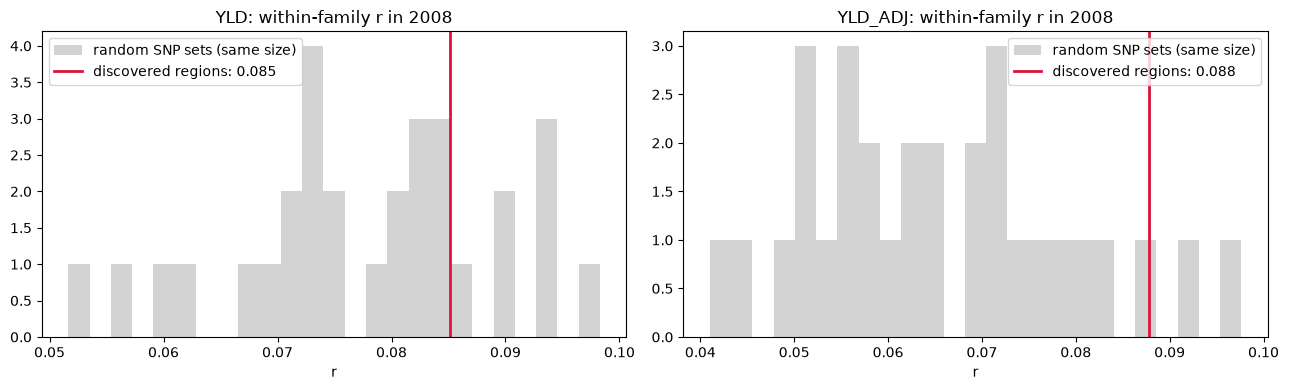

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, ax in zip(("YLD", "YLD_ADJ"), axes):
    if name not in null_store:
        continue
    ax.hist(null_store[name], bins=25, color="lightgray", label="random SNP sets (same size)")
    obs = marker_test.set_index("target").loc[name, "r_within_2008"]
    ax.axvline(obs, color="crimson", lw=2, label=f"discovered regions: {obs:.3f}")
    ax.set_title(f"{name}: within-family r in 2008"); ax.set_xlabel("r"); ax.legend()
plt.tight_layout(); plt.show()

## Parte 3. Líneas propuestas a fin de 2007 y comparación con 2008 por distancia genética

**Propuestas** (tres criterios, sobre las líneas de años < t):
- `phenotype_global`: el mejor q% de todas las líneas por su rendimiento ajustado observado.
- `phenotype_within`: el mejor q% dentro de cada familia por rendimiento observado.
- `genomic_within`: el mejor q% dentro de cada familia según marcadores, con validación cruzada por año (el puntaje de una línea nunca usa su propio año).

**Comparación con el año t** (2008 y años anteriores como retrospectiva): cada línea del año t se compara con sus `knn` parientes más cercanos entre las líneas anteriores (espacio de componentes principales). `s` = fracción de esos parientes que fueron propuestos.
- **Concordancia:** `mean_s / q` (1 = lo esperado si la propuesta fuera irrelevante) y su z frente a propuestas al azar.
- **Resultado:** correlación entre `s` y el rendimiento observado del año t (global y agrupada dentro de familia), su valor p frente a propuestas al azar del mismo tamaño y estructura, y diferencia de rendimiento entre el tercil superior e inferior de `s` con intervalo por remuestreo de familias.

In [10]:
TARGET = "YLD_ADJ"   # or "YLD"
tgt = TARGETS[TARGET]
tgt_w = wf(tgt)
tgt_std_w = tgt_w / np.nanstd(tgt_w[years <= 2007])


def year_stats():
    st = {}
    for yr in range(int(years.min()), 2008):
        idx = np.where((years == yr) & ~np.isnan(tgt_std_w))[0]
        Xy = Xw[idx].astype(np.float64)
        st[yr] = (Xy.T @ Xy, Xy.T @ tgt_std_w[idx])
    return st


ST = year_stats()


def genomic_scores(t):
    """Leave-one-year-out within-family ridge scores for every line of the years < t."""
    pool = [y for y in ST if y < t]
    A = sum(ST[y][0] for y in pool)
    b = sum(ST[y][1] for y in pool)
    scores = np.full(len(X), np.nan)
    for y in pool:
        beta = np.linalg.solve(A - ST[y][0] + CFG["ridge_lambda"] * np.eye(A.shape[0]), b - ST[y][1])
        idx = np.where(years == y)[0]
        scores[idx] = Xw[idx] @ beta
    return scores


def propose(score, q, pool_mask, mode):
    prop = np.zeros(len(X), bool)
    idx = np.where(pool_mask & ~np.isnan(score))[0]
    if mode == "global":
        k = int(round(len(idx) * q))
        prop[idx[np.argsort(-score[idx])[:k]]] = True
    else:
        rank = pd.DataFrame({"s": score[idx], "c": codes[idx]}).groupby("c")["s"].rank(ascending=False, pct=True)
        prop[idx[rank.to_numpy() <= q]] = True
    return prop


def neighbors(t):
    pool = np.where(years < t)[0]
    test = np.where(years == t)[0]
    g = np.random.default_rng(0)
    fit_rows = g.choice(pool, size=min(20000, len(pool)), replace=False)
    pca = PCA(n_components=CFG["n_pcs"], svd_solver="randomized", random_state=0).fit(X[fit_rows])
    ind = NearestNeighbors(n_neighbors=CFG["knn"], n_jobs=-1).fit(pca.transform(X[pool])).kneighbors(pca.transform(X[test]))[1]
    return pool, test, ind


def fast_r(s, y, gidx, ng):
    """Pearson r (all lines) and pooled within-family r."""
    if s.std() == 0:
        return np.nan, np.nan
    r_all = np.corrcoef(s, y)[0, 1]
    cnt = np.bincount(gidx, minlength=ng)
    sw = s - (np.bincount(gidx, weights=s, minlength=ng) / np.maximum(cnt, 1))[gidx]
    yw_ = y - (np.bincount(gidx, weights=y, minlength=ng) / np.maximum(cnt, 1))[gidx]
    r_w = np.corrcoef(sw, yw_)[0, 1] if sw.std() > 0 and yw_.std() > 0 else np.nan
    return r_all, r_w


def proposal_test(t, kind, q, nb, scores, n_null, n_boot):
    pool, test, ind = nb
    mode = "global" if kind == "phenotype_global" else "within"
    prop = propose(scores[kind], q, years < t, mode)
    s = prop[pool][ind].mean(axis=1)
    y = tgt[test]
    m = ~np.isnan(y)
    gid, inv = np.unique(codes[test][m], return_inverse=True)
    obs_all, obs_w = fast_r(s[m], y[m], inv, len(gid))
    g = np.random.default_rng(3)
    null_s, null_all, null_w = [], [], []
    for _ in range(n_null):
        pr = propose(g.random(len(X)), q, years < t, mode)      # random proposal, same size and structure
        sr = pr[pool][ind].mean(axis=1)
        a, w_ = fast_r(sr[m], y[m], inv, len(gid))
        null_s.append(sr.mean()); null_all.append(a); null_w.append(w_)
    null_s, null_all, null_w = map(np.array, (null_s, null_all, null_w))
    # tercile contrast with a bootstrap over test families
    def contrast(idx_rows):
        ss, yy = s[m][idx_rows], y[m][idx_rows]
        lo, hi = np.quantile(ss, [1 / 3, 2 / 3])
        return yy[ss >= hi].mean() - yy[ss <= lo].mean() if (ss >= hi).any() and (ss <= lo).any() else np.nan
    fam_rows = [np.where(inv == k)[0] for k in range(len(gid))]
    obs_c = contrast(np.arange(m.sum()))
    bg = np.random.default_rng(4)
    boots = []
    for _ in range(n_boot):
        pick = bg.integers(0, len(fam_rows), len(fam_rows))
        boots.append(contrast(np.concatenate([fam_rows[i] for i in pick])))
    lo_c, hi_c = np.nanpercentile(boots, [2.5, 97.5])
    return dict(year=t, kind=kind, q=q, mean_s_over_q=s.mean() / q, z_concordance=(s.mean() - null_s.mean()) / (null_s.std() + 1e-9),
                r_all=obs_all, p_r_all=(np.nansum(null_all >= obs_all) + 1) / (len(null_all) + 1),
                r_within=obs_w, p_r_within=(np.nansum(null_w >= obs_w) + 1) / (len(null_w) + 1),
                top_minus_bottom_tercile=obs_c, ci_low=lo_c, ci_high=hi_c)

In [11]:
results = []
for t in CFG["backtest_years"]:
    t0 = time.time()
    nb = neighbors(t)
    gs = genomic_scores(t)
    scores = {"phenotype_global": tgt, "phenotype_within": tgt_w, "genomic_within": gs}
    for kind in scores:
        for q in CFG["budgets"]:
            results.append(proposal_test(t, kind, q, nb, scores, CFG["n_null"], CFG["n_boot"]))
    print(f"year {t} done ({time.time() - t0:.0f}s)")
res3 = pd.DataFrame(results)
res3.to_csv(DATA_DIR / "proposal2007_results.csv", index=False)
res3[res3.q == 0.2].round(3) if 0.2 in CFG["budgets"] else res3.round(3)

year 2008 done (6s)


,year,kind,q,mean_s_over_q,z_concordance,r_all,p_r_all,r_within,p_r_within,top_minus_bottom_tercile,ci_low,ci_high
0,2008,phenotype_global,0.2,0.843,-3.824,-0.076,0.935,0.004,0.484,-2.733,-6.547,1.695
2,2008,phenotype_within,0.2,0.812,-5.024,-0.154,1.000,-0.006,0.871,-4.963,-8.566,-1.645
4,2008,genomic_within,0.2,1.058,1.632,-0.119,1.000,0.013,0.323,-3.200,-7.344,0.379


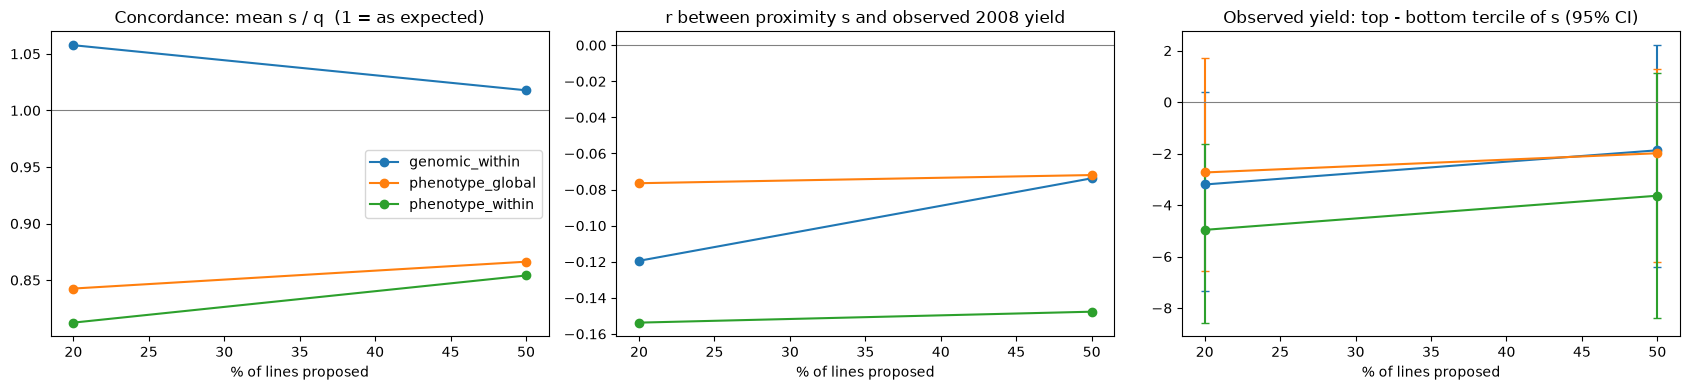

In [12]:
# Main figure: 2008 outcome by proposal type and budget (vs random proposals)
d = res3[res3.year == max(CFG["backtest_years"])]
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for kind, sub_ in d.groupby("kind"):
    sub_ = sub_.sort_values("q")
    axes[0].plot(sub_["q"] * 100, sub_["mean_s_over_q"], "o-", label=kind)
    axes[1].plot(sub_["q"] * 100, sub_["r_all"], "o-", label=kind)
    axes[2].errorbar(sub_["q"] * 100, sub_["top_minus_bottom_tercile"],
                     yerr=[sub_["top_minus_bottom_tercile"] - sub_["ci_low"], sub_["ci_high"] - sub_["top_minus_bottom_tercile"]], fmt="o-", capsize=3, label=kind)
axes[0].axhline(1, color="gray", lw=0.8); axes[0].set_title("Concordance: mean s / q  (1 = as expected)")
axes[1].axhline(0, color="gray", lw=0.8); axes[1].set_title("r between proximity s and observed 2008 yield")
axes[2].axhline(0, color="gray", lw=0.8); axes[2].set_title("Observed yield: top - bottom tercile of s (95% CI)")
for ax in axes:
    ax.set_xlabel("% of lines proposed")
axes[0].legend()
plt.tight_layout(); plt.show()

In [13]:
# Consistency across backtest years (q = 0.2 or the closest budget)
q0 = 0.2 if 0.2 in CFG["budgets"] else CFG["budgets"][0]
piv = res3[res3.q == q0].pivot(index="year", columns="kind", values="r_within")
piv_p = res3[res3.q == q0].pivot(index="year", columns="kind", values="p_r_within")
print(f"pooled within-family r between proximity to the proposal and observed yield (q={q0}); p vs random proposals in the second table")
display(piv.round(3)); display(piv_p.round(3))

pooled within-family r between proximity to the proposal and observed yield (q=0.2); p vs random proposals in the second table


kind,genomic_within,phenotype_global,phenotype_within
year,,,
2008,0.013,0.004,-0.006


kind,genomic_within,phenotype_global,phenotype_within
year,,,
2008,0.323,0.484,0.871


## Parte 4. Presupuesto de parcelas: ¿cuántos ambientes por línea?

Confiabilidad medida de la media de una línea (dentro de familia) cuando se promedian `m` observaciones: se parten al azar las observaciones de cada línea en dos grupos de `m` y se correlacionan. La curva teórica (Spearman-Brown) se ajusta con la repetibilidad de una sola observación.

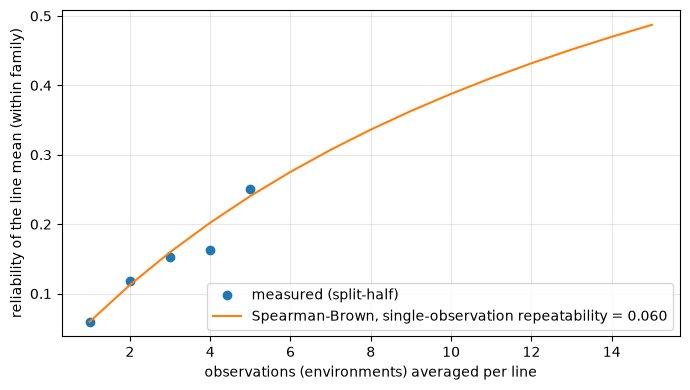

,reliability,n_lines
1,0.060,15000.0
2,0.118,15000.0
3,0.153,15000.0
4,0.162,15000.0
5,0.251,1283.0


In [14]:
def adjusted_obs(df):
    out = []
    for yr, d in df[df["YLD_BE"].notna()].groupby("YEAR"):
        d = d.copy()
        y = d["YLD_BE"].to_numpy(float)
        env, eu = pd.factorize(d["ENV"]); te_, tu = pd.factorize(d["TESTER"]); li, lu = pd.factorize(d["LINE_ID"])
        mu = y.mean(); e = np.zeros(len(eu)); tt = np.zeros(len(tu)); l = np.zeros(len(lu))
        for _ in range(20):
            e = bd.group_means(env, y - mu - tt[te_] - l[li], len(eu))
            tt = bd.group_means(te_, y - mu - e[env] - l[li], len(tu))
            l = bd.group_means(li, y - mu - e[env] - tt[te_], len(lu))
        d["yadj"] = y - e[env] - tt[te_]
        out.append(d[["LINE_ID", "yadj"]])
    return pd.concat(out)


obs_adj = adjusted_obs(ph)
grp = obs_adj.groupby("LINE_ID")["yadj"].apply(np.asarray)
pop_of = pd.Series(grp.index.str.extract(r"^(C\d+\.\d+)\.")[0].to_numpy(), index=grp.index)
g = np.random.default_rng(0)
rel = {}
for m_ in range(1, 7):
    ids = np.array([i for i, v in grp.items() if len(v) >= 2 * m_])
    if len(ids) < 500:
        break
    ids = g.choice(ids, size=min(len(ids), 15000), replace=False)
    a, b = [], []
    for i in ids:
        v = g.permutation(grp[i])
        a.append(v[:m_].mean()); b.append(v[m_:2 * m_].mean())
    df_ = pd.DataFrame({"a": a, "b": b, "pop": pop_of[ids].to_numpy()})
    for c in ("a", "b"):
        df_[c] = df_[c] - df_.groupby("pop")[c].transform("mean")
    rel[m_] = (df_["a"].corr(df_["b"]), len(ids))
rel = pd.DataFrame(rel, index=["reliability", "n_lines"]).T
rho = rel.loc[1, "reliability"]
mm = np.arange(1, 16)
plt.figure(figsize=(7, 4))
plt.plot(rel.index, rel["reliability"], "o", label="measured (split-half)")
plt.plot(mm, mm * rho / (1 + (mm - 1) * rho), "-", label=f"Spearman-Brown, single-observation repeatability = {rho:.3f}")
plt.xlabel("observations (environments) averaged per line"); plt.ylabel("reliability of the line mean (within family)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
rel.round(3)

## Resumen de evidencia

In [15]:
ev = []
for _, r in marker_test.iterrows():
    ev.append(dict(claim=f"Regions found <=2007 for {r['target']} predict 2008 (within-family r)", value=round(r["r_within_2008"], 3),
                   uncertainty=f"95% CI {r['ci95_low']:.3f} to {r['ci95_high']:.3f}; p vs random SNPs = {r['p_vs_random']:.3f}"))
last = max(CFG["backtest_years"])
for _, r in res3[(res3.year == last) & (res3.q == q0)].iterrows():
    ev.append(dict(claim=f"Proposal '{r['kind']}' (top {int(r['q']*100)}%): {last} lines near it yield more", value=round(r["top_minus_bottom_tercile"], 2),
                   uncertainty=f"95% CI {r['ci_low']:.2f} to {r['ci_high']:.2f}; p(r_all) vs random = {r['p_r_all']:.3f}; concordance mean_s/q = {r['mean_s_over_q']:.2f}"))
m4 = rel["reliability"].get(4, np.nan)
ev.append(dict(claim="Reliability of a line mean (within family): 1 vs 4 observations", value=f"{rel['reliability'].get(1, np.nan):.2f} vs {m4:.2f}", uncertainty="measured by random split-halves; Spearman-Brown predicts " + f"{rho*4/(1+3*rho):.2f} for 4 and {rho*7/(1+6*rho):.2f} for 7 observations"))
evidence = pd.DataFrame(ev)
evidence.to_csv(DATA_DIR / "proposal2007_evidence.csv", index=False)
pd.set_option("display.max_colwidth", 200)
evidence

,claim,value,uncertainty
0,Regions found <=2007 for YLD predict 2008 (within-family r),0.085,95% CI 0.052 to 0.119; p vs random SNPs = 0.258
1,Regions found <=2007 for YLD_ADJ predict 2008 (within-family r),0.088,95% CI 0.059 to 0.123; p vs random SNPs = 0.097
2,Regions found <=2007 for ERM predict 2008 (within-family r),0.181,95% CI 0.141 to 0.224; p vs random SNPs = 0.129
3,Regions found <=2007 for MST predict 2008 (within-family r),0.212,95% CI 0.176 to 0.248; p vs random SNPs = 0.097
4,Proposal 'phenotype_global' (top 20%): 2008 lines near it yield more,-2.73,95% CI -6.55 to 1.70; p(r_all) vs random = 0.935; concordance mean_s/q = 0.84
5,Proposal 'phenotype_within' (top 20%): 2008 lines near it yield more,-4.96,95% CI -8.57 to -1.64; p(r_all) vs random = 1.000; concordance mean_s/q = 0.81
6,Proposal 'genomic_within' (top 20%): 2008 lines near it yield more,-3.2,95% CI -7.34 to 0.38; p(r_all) vs random = 1.000; concordance mean_s/q = 1.06
7,Reliability of a line mean (within family): 1 vs 4 observations,0.06 vs 0.16,measured by random split-halves; Spearman-Brown predicts 0.20 for 4 and 0.31 for 7 observations
